In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
runs = [
    "20220719_K562_1", 
    "20220719_K562_2", 
    "20220719_K562_3", 
    "20220719_K562_4", 
    "20220729_K562_1", 
    "20220729_K562_2",
]
d = info[info["Run"].isin(runs)]
d1 = d[d["UMIs"] >= 5000]
print("K562 cells:", len(d1))
runs = [
    "20220818_mESC_1", 
    "20220818_mESC_2", 
    "20220818_mESC_3", 
]
d = info[info["Run"].isin(runs)]
d2 = d[d["UMIs"] >= 5000]
print("mESC cells:", len(d2))

K562 cells: 426
mESC cells: 213


Isoforms: 1877612


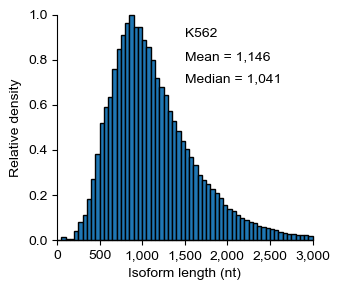

Isoforms: 746718


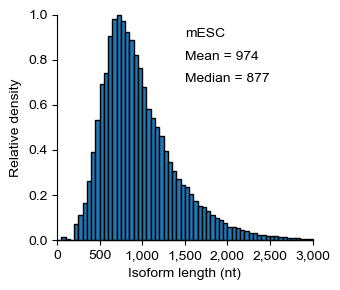

In [15]:
for name, d in zip(["K562", "mESC"], [d1, d2]):
    lengths = []
    for cell in d.index:
        path = "../../../1_NanoNASCseq/results/6_assembly/2_sqanti3/%s/%s/%s_classification.txt" % (cell.split(".")[0], cell, cell)
        if os.path.exists(path):
            tmp = pd.read_csv(path, sep="\t")
            lengths.extend(tmp["length"])
    print("Isoforms:", len(lengths))

    plt.figure(figsize=(3.5, 3))
    ret = plt.hist(lengths, bins=60, range=(0, 3000), color="C0", edgecolor="black", clip_on=False)
    vmax = max(ret[0])
    plt.text(1500, vmax * 0.9, "%s" % name)
    plt.text(1500, vmax * 0.8, "Mean = %s" % format(int(np.mean(lengths)), ","))
    plt.text(1500, vmax * 0.7, "Median = %s" % format(int(np.median(lengths)), ","))
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.xlabel("Isoform length (nt)")
    plt.ylabel("Relative density")
    xlim = 3000
    plt.xlim(0, xlim)
    plt.ylim(0, vmax)
    xs = np.arange(0, xlim + 1, 500)
    ys = np.arange(0, 1.1, 0.2)
    plt.xticks(xs, [format(x, ",") for x in xs])
    plt.yticks([vmax * y for y in ys], ["%.1f" % y for y in ys])
    plt.tight_layout()
    plt.savefig("figures/isoform_lengths.hist.%s.pdf" % name)
    plt.show()
    plt.close()